<a href="https://colab.research.google.com/github/gnn59lll-coder/Laboratory-works-for-II/blob/main/%D0%9B%D0%B0%D0%B1%D0%B0_4_%D0%9A%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Кластеризация

In [1]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [2]:
das = pd.read_csv('/content/sample_data/data_about_students.csv', sep=';')

In [5]:
das.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [6]:
das.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation rat

## Названия столбцов:
Marital status (Семейное положение)

Application mode (Способ подачи заявления)

Application order (Очередность заявления)

Course (Номер учебной программы)

Daytime/evening attendance (Посещаемость: дневная/вечерняя(заочная))

Previous qualification (Предыдущая квалификация)

Previous qualification (grade) (Оценка за предыдущую квалификацию)

Nacionality (Национальность)

Mother's qualification (Образование матери)

Father's qualification (Образование отца)

Mother's occupation (Профессия матери)

Father's occupation (Профессия отца)

Admission grade (Проходной балл на поступление в вуз)

Displaced (Перемещенное лицо(беженец или переселенец))

Educational special needs (Особые образовательные потребности)

Debtor (Должен ли за обучение)

Tuition fees up to date (Актуальность оплаты обучения)

Gender (Пол)

Scholarship holder (Получатель стипендии)

Age at enrollment (Возраст на момент зачисления)

International (Иностранный студент)

Curricular units 1st sem (credited) / Curricular units 2nd sem (credited) (Количество учебных дисциплин, которые были зачтены студенту в начале семестра ).

Curricular units 1st sem (enrolled) / Curricular units 2nd sem (enrolled) (Количество учебных дисциплин, на которые студент официально записался в данном семестре.)

Curricular units 1st sem (evaluations) / Curricular units 2nd sem (evaluations) ( Общее количество оценок или аттестаций, полученных студентом в течение семестра.)

Curricular units 1st sem (approved) / Curricular units 2nd sem (approved) ( Количество дисциплин, которые студент успешно сдал в семестре.)

Curricular units 1st sem (grade) / Curricular units 2nd sem (grade) (Средний балл студента по всем сданным дисциплинам за семестр.)

Curricular units 1st sem (without evaluations) / Curricular units 2nd sem (without evaluations) ( Количество дисциплин, по которым студент не был аттестован.)

Unemployment rate (Уровень безработицы)

Inflation rate (Уровень инфляции)

GDP (ВВП)

Target (Статус студента на момент сбора данных.)

Dropout — студент отчислен.

Graduate — студент успешно закончил обучение.

Enrolled — студент все еще учится.

In [8]:
vals = das["Target"].unique()
vals

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [12]:
cols_for_clusters = [
    'Age at enrollment',
    'Admission grade',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'GDP',
    'Unemployment rate'
]

das_1 = das[cols_for_clusters].copy()

In [13]:
das_1.head()

,Age at enrollment,Admission grade,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),GDP,Unemployment rate
0,20,127.3,0.000000,0.000000,1.74,10.8
1,19,142.5,14.000000,13.666667,0.79,13.9
2,19,124.8,0.000000,0.000000,1.74,10.8
3,20,119.6,13.428571,12.400000,-3.12,9.4
4,45,141.5,12.333333,13.000000,0.79,13.9


In [14]:
das

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [15]:
X = das_1
y = das["Target"].replace(vals, [0, 1, 2])
yvals = das["Target"]

/tmp/ipykernel_20671/3622457930.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = das["Target"].replace(vals, [0, 1, 2])


### Распространенные алгоритмы кластеризации

In [20]:
import mpl_toolkits.mplot3d  # noqa: F401
from sklearn.cluster import KMeans

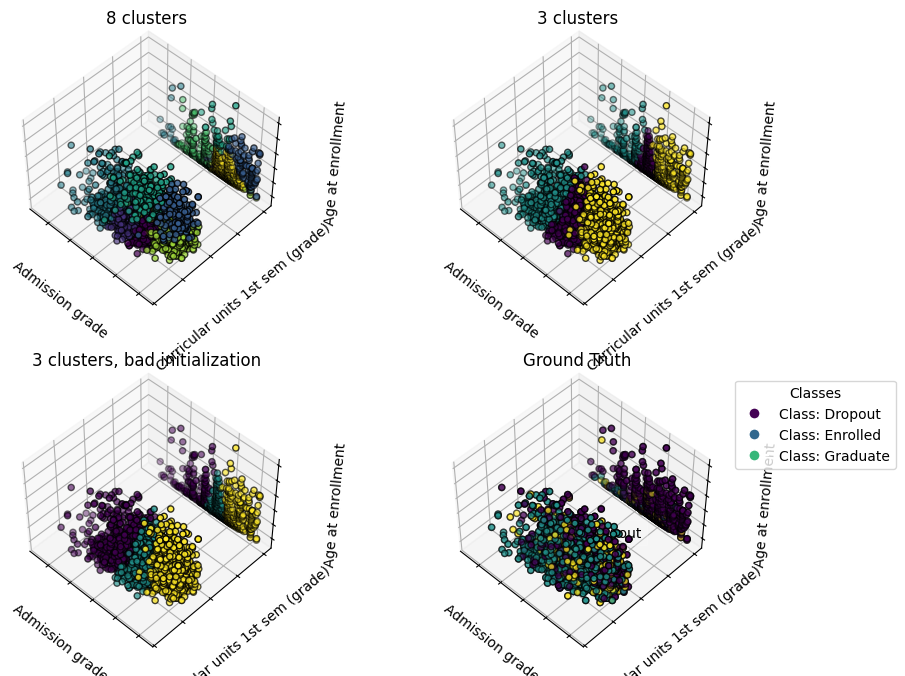

In [22]:
cols_for_clusters = ['Age at enrollment','Admission grade','Curricular units 1st sem (grade)']

estimators = [
    ("k_means_iris_8", KMeans(n_clusters=8)),
    ("k_means_iris_3", KMeans(n_clusters=3)),
    ("k_means_iris_bad_init", KMeans(n_clusters=3, n_init=1, init="random")),
]

fig = plt.figure(figsize=(10, 8))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]
for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X)
    labels = est.labels_

    ax.scatter(X["Admission grade"], X["Curricular units 1st sem (grade)"], X["Age at enrollment"], c=labels.astype(float), edgecolor="k")

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("Admission grade")
    ax.set_ylabel("Curricular units 1st sem (grade)")
    ax.set_zlabel("Age at enrollment")
    ax.set_title(title)

# Plot the ground truth
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

for name, label in [(vals[0], 0), (vals[1], 1), (vals[2], 2)]:
    ds = das[das["Target"]==name]
    ax.text3D(
        ds["Admission grade"].mean(),
        ds["Curricular units 1st sem (grade)"].mean(),
        ds["Age at enrollment"].mean(),
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )
unique_classes = sorted(list(set(vals)))
scatter_gt = ax.scatter(
    X["Admission grade"],
    X["Curricular units 1st sem (grade)"],
    X["Age at enrollment"],
    c=y,
    edgecolor="k",
    label="Data Points"
)

# Создаем_handles_ для легенды вручную
legend_handles = []
legend_labels = []
for i, cls_name in enumerate(unique_classes):
    handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter_gt.cmap(i / len(unique_classes)), markersize=8, label=f"Class: {cls_name}")
    legend_handles.append(handle)
    legend_labels.append(f"Class: {cls_name}")

ax.scatter(X["Admission grade"], X["Curricular units 1st sem (grade)"], X["Age at enrollment"], c=y, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Admission grade")
ax.set_ylabel("Curricular units 1st sem (grade)")
ax.set_zlabel("Age at enrollment")
ax.set_title("Ground Truth")

plt.subplots_adjust(wspace=0.25, hspace=0.25)
ax.legend(handles=legend_handles, title="Classes", loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

In [23]:
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score

n_clusters = np.arange(2, 21)

In [24]:
best_metric = [0, 10000, 0,[]]

silhouette_score_values = []
adjusted_rand_score_values = []


for n in n_clusters:

    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10)
    clusterer.fit(X)
    y_pred = clusterer.predict(X)

    score1 = metrics.silhouette_score(X, y_pred)
    silhouette_score_values.append(score1)

    score2 = metrics.adjusted_rand_score(y, y_pred)
    adjusted_rand_score_values.append(score2)


    if score1 < best_metric[1] and score2 > best_metric[2]:
          best_metric[1] = score1
          best_metric[2] = score2
          best_metric[3] = clusterer.cluster_centers_
          best_metric[0] = n

In [25]:
best_metric

[np.int64(7),
 np.float64(0.27581328544849476),
 0.06882783740012008,
 array([[ 4.02124183e+01,  1.26410784e+02,  1.02699906e+01,
          9.94949443e+00, -3.00424837e-01,  1.14852941e+01],
        [ 1.96968774e+01,  1.27218507e+02,  1.27486084e+01,
          1.27009966e+01, -9.65727342e-02,  1.14191165e+01],
        [ 2.71713483e+01,  1.57373876e+02,  9.90901232e+00,
          9.08829762e+00, -4.26966292e-02,  1.21584270e+01],
        [ 3.13068182e+01,  1.03779545e+02,  7.67334927e+00,
          6.31484886e+00, -2.77556818e-01,  1.16295455e+01],
        [ 2.04103376e+01,  1.14698101e+02,  1.22614788e+01,
          1.20987275e+01,  4.28544304e-01,  1.15937764e+01],
        [ 2.22639175e+01,  1.26524124e+02,  1.39560137e+00,
          2.28178694e-01, -3.35958763e-01,  1.14057732e+01],
        [ 2.09608434e+01,  1.40629669e+02,  1.30483114e+01,
          1.27996313e+01,  1.46114458e-01,  1.16206325e+01]])]

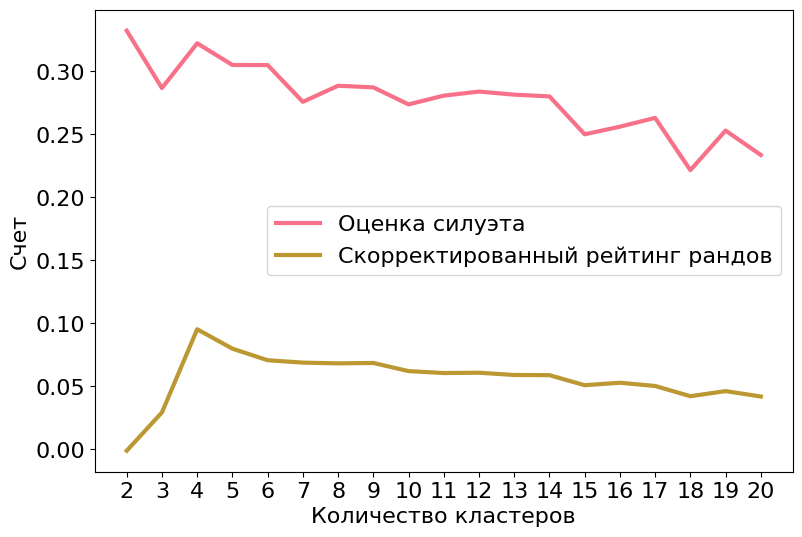

In [26]:
plt.figure(figsize=(9, 6))
plt.plot(n_clusters, silhouette_score_values, linewidth=3, label='Оценка силуэта') #Silhouette score
plt.plot(n_clusters, adjusted_rand_score_values, linewidth=3, label='Скорректированный рейтинг рандов') #Adjusted rand score
plt.xlabel('Количество кластеров', size=16) #Number of clusters
plt.ylabel('Счет', size=16) #Score
plt.xticks(n_clusters, size=16)
plt.yticks(size=16)
plt.legend(loc='best', fontsize=16)

plt.show()

### Иерархическая кластеризация

In [30]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [31]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
das[['Target']] = enc.fit_transform(das[['Target']])
das.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0.0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2.0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0.0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2.0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2.0


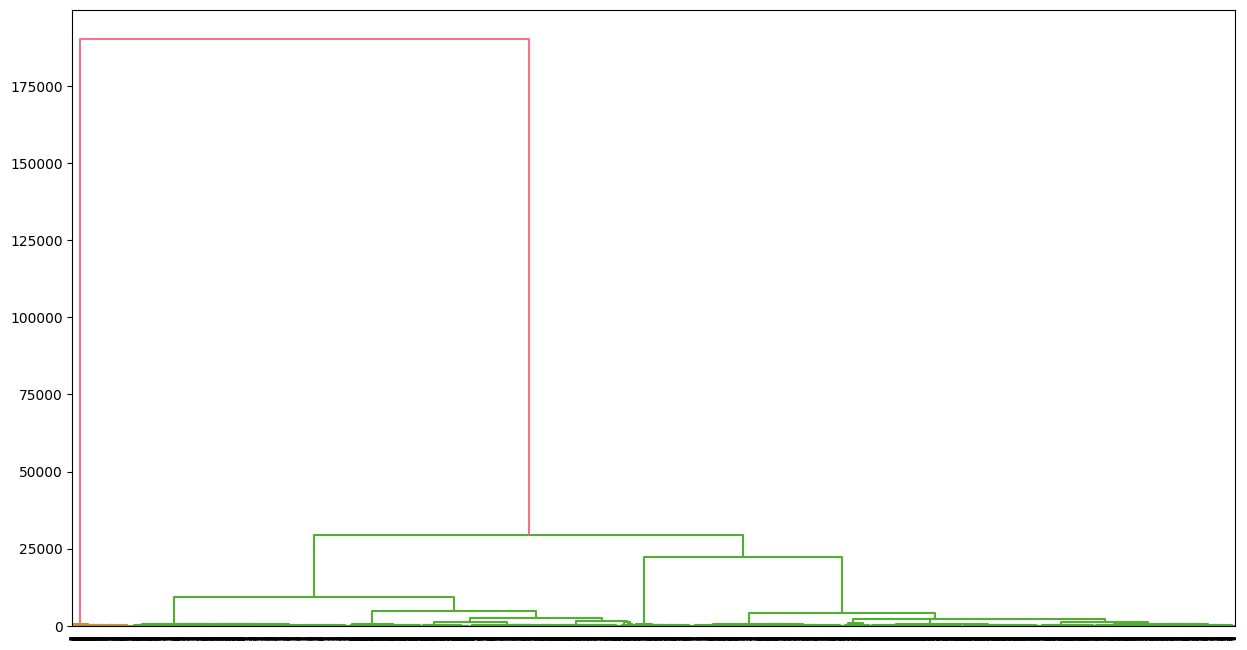

In [35]:
samples = das.values

# Реализация иерархической кластеризации при помощи функции linkage
mergings = linkage(samples, method='ward')
plt.figure(figsize=(15, 8))
# Строим дендрограмму, указав параметры удобные для отображения
dendrogram(mergings,
           labels=list(y),
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()

### DBSCAN

In [36]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

In [ ]:
mins = X.shape[1]

['y', 'b', 'g', 'r']


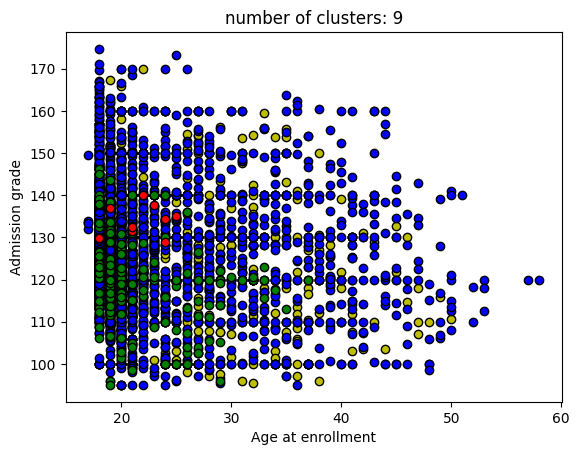

In [58]:
db = DBSCAN(eps=6, min_samples=5).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Plot result

# Black removed and is used for noise instead.
unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
	if k == -1:
		# Black used for noise.
		col = 'k'

	class_member_mask = (labels == k)

	xy = X[class_member_mask & core_samples_mask]
	plt.plot(xy["Age at enrollment"], xy["Admission grade"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

	xy = X[class_member_mask & ~core_samples_mask]
	plt.plot(xy["Age at enrollment"], xy["Admission grade"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

plt.xlabel('Age at enrollment')
plt.ylabel('Admission grade')
plt.title('number of clusters: %d' % n_clusters_)
plt.show()

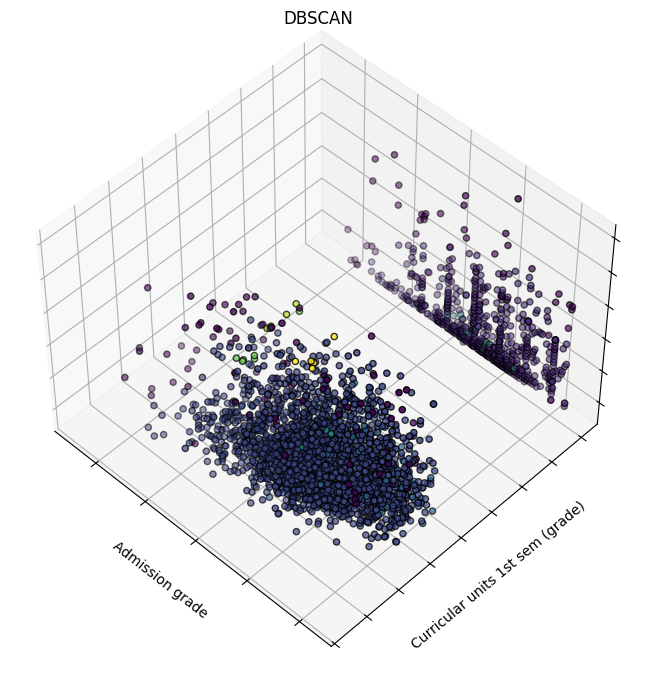

In [66]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

ax.scatter(X["Admission grade"], X["Curricular units 1st sem (grade)"], X["Age at enrollment"], c=labels.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Admission grade")
ax.set_ylabel("Curricular units 1st sem (grade)")
ax.set_zlabel("Age at enrollment")
ax.set_title("DBSCAN")
plt.show()

In [67]:
# evaluation metrics
print(X)
print(labels)
print(f"Number of unique labels: {len(np.unique(labels))}")

# Проверяем, что есть минимум 2 кластера для silhouette_score
if len(np.unique(labels)) >= 2:
    sc = metrics.silhouette_score(X, labels)
    print("Silhouette Coefficient:%0.2f" % sc)
else:
    print("Silhouette Coefficient: N/A (требуется минимум 2 кластера)")

# Adjusted Rand Index требует минимум 2 кластера в обоих наборах меток
if len(np.unique(labels)) >= 2 and len(np.unique(y)) >= 2:
    ari = adjusted_rand_score(y, labels)
    print("Adjusted Rand Index: %0.2f" % ari)
else:
    print("Adjusted Rand Index: N/A (требуется минимум 2 кластера в обоих наборах)")

      Age at enrollment  Admission grade  Curricular units 1st sem (grade)  \
0                    20            127.3                          0.000000   
1                    19            142.5                         14.000000   
2                    19            124.8                          0.000000   
3                    20            119.6                         13.428571   
4                    45            141.5                         12.333333   
...                 ...              ...                               ...   
4419                 19            122.2                         13.600000   
4420                 18            119.0                         12.000000   
4421                 30            149.5                         14.912500   
4422                 20            153.8                         13.800000   
4423                 22            152.0                         11.666667   

      Curricular units 2nd sem (grade)   GDP  Unemployment rate